# Violin Plot

This section showcases the violin plot. It contains examples of how to create violin plots using the [datachart.charts.ViolinPlot](../../../references/charts/#datachart.charts.ViolinPlot) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-violin-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the violin plots are created using the `ViolinPlot` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import ViolinPlot

## Violin Plot Input Attributes

The `ViolinPlot` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the data points. For a single violin plot, `data` is a list of dictionaries; the points that share a `label` form one violin. For multiple violin plots, `data` is a list of lists.

```python
ViolinPlot(
    data=[{                                             # A list of violin data points (or list of lists for multiple charts)
        "label": str,                                   # The category label
        "value": Union[int, float],                     # The numeric value
    }],
    style={                                             # The style of the violin (optional)
        "plot_violin_color":           Union[str, None],        # The fill color of the body
        "plot_violin_alpha":           Union[float, None],      # The alpha of the body
        "plot_violin_linewidth":       Union[int, float, None], # The line width of the body edge
        "plot_violin_edgecolor":       Union[str, None],        # The edge color of the body (default: the fill)
        "plot_violin_width":           Union[int, float, None], # The maximum width of the body
        "plot_violin_inner_color":     Union[str, None],        # The color of the inner marks (default: the font color)
        "plot_violin_inner_linewidth": Union[int, float, None], # The line width of the inner marks
        "plot_violin_median_color":    Union[str, None],        # The color of the median dot
        "plot_violin_median_size":     Union[int, float, None], # The size of the median dot
    },
    subtitle=Optional[str],                             # The subtitle of the chart (or list for multiple charts)
    title=Optional[str],                                # The title of the chart
    xlabel=Optional[str],                               # The x-axis label
    ylabel=Optional[str],                               # The y-axis label
    emphasis=Optional[Union[str, List[Optional[str]]]], # The emphasis role per violin label ("background", "highlight", None)

    inner=Optional[str],                                # The inner marks ("box", "quartiles", "median", None; default: "box")
    bandwidth=Optional[Union[str, float]],              # The KDE bandwidth ("scott", "silverman", or a number; default: "scott")
    split=Optional[str],                                # The key in data whose two values split each violin in half

    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    show_grid=Optional[str],                            # Which grid lines to show ("both", "x", "y")
    show_legend=Optional[bool],                         # Whether to show the legend (the split values)
    orientation=Optional[ORIENTATION],                  # The orientation of the violins
    scaley=Optional[str],                               # The y-axis scale ("linear", "log", ...)
    xmin=Optional[Union[int, float]],                   # The x-axis range
    xmax=Optional[Union[int, float]],
    ymin=Optional[Union[int, float]],                   # The y-axis range
    ymax=Optional[Union[int, float]],

    subplots=Optional[bool],                            # Whether to draw each chart in its own subplot (required for multiple charts)
    max_cols=Optional[int],                             # Maximum number of subplots per row
    sharex=Optional[bool],                              # Whether subplots share the x-axis
    sharey=Optional[bool],                              # Whether subplots share the y-axis

    xticks=Optional[List[Union[int, float]]],           # the x-axis ticks
    xticklabels=Optional[List[str]],                    # the x-axis tick labels (must be same length as xticks)
    xtickrotate=Optional[int],                          # the x-axis tick labels rotation
    yticks=Optional[List[Union[int, float]]],           # the y-axis ticks
    yticklabels=Optional[List[str]],                    # the y-axis tick labels (must be same length as yticks)
    ytickrotate=Optional[int],                          # the y-axis tick labels rotation

    vlines=Optional[Union[dict, List[dict]]],           # the vertical lines
    hlines=Optional[Union[dict, List[dict]]],           # the horizontal lines

    label=Optional[str],                                # The key in data holding the category label (default: "label")
    value=Optional[str],                                # The key in data holding the numeric value (default: "value")
)
```

For more details, see the [datachart.charts.ViolinPlot](../../../references/charts/#datachart.charts.ViolinPlot) function.

## Basics

The examples in this guide share one dataset: the body mass of the 342 penguins of the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), three species measured on the islands of the Palmer Archipelago in Antarctica — the same data the [Box Plot](../boxplot/) guide uses. The data is hard-coded in a hidden cell, which keeps the flipper length of every penguin alongside its species. `chart_data` holds the body mass (in g) of every penguin, labeled with its species and carrying its sex.

In [2]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]

chart_data = [
    {"label": penguin["species"], "value": mass, "sex": penguin["sex"]}
    for penguin in PENGUINS
    for mass in penguin["body_mass"]
]
flipper_data = [
    {"label": penguin["species"], "value": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

The data is a flat list of dictionaries, one per data point, each with a `label` and a `value`; extra keys like `sex` are ignored until a section asks for them. The points that share a `label` are grouped into one violin, so three species give three violins:

In [3]:
chart_data[:3]

[{'label': 'Adelie', 'value': 3800, 'sex': 'Female'},
 {'label': 'Adelie', 'value': 3250, 'sex': 'Female'},
 {'label': 'Adelie', 'value': 3450, 'sex': 'Female'}]

**Basic example.** Only the `data` argument is required to draw the violin plot. Each body is a kernel density estimate of its values, mirrored around the category position and scaled to the same maximum width; inside it, a thin bar spans the middle half of the values (the first to the third quartile), the line through it reaches the furthest values within 1.5 times the bar height, and the dot is the median. Where a box plot draws these summaries alone, the violin shows the shape of the distribution around them: the Gentoo are the heaviest species, and the Adelie have a wider spread than their box would suggest.

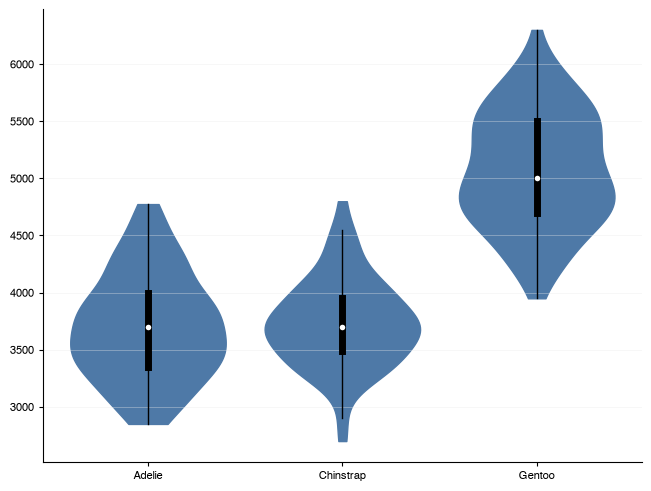

In [4]:
ViolinPlot(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Violin Plot

Every customization is either a keyword argument of `ViolinPlot` or a `plot_violin_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| change the body fill, edge or transparency  | `style={"plot_violin_color": ..., "plot_violin_edgecolor": ..., "plot_violin_alpha": ...}` | [Violin style](#violin-style) |
| style the inner marks and the median dot    | `style={"plot_violin_inner_color": ..., "plot_violin_median_color": ..., ...}` | [Violin style](#violin-style) |
| change what is drawn inside the body        | `inner`                                                                 | [Inner marks](#inner-marks) |
| smooth or sharpen the body                  | `bandwidth`                                                             | [Bandwidth](#bandwidth) |
| compare two groups within each category     | `split`, `show_legend`                                                  | [Split violins](#split-violins) |
| draw the violins horizontally               | `orientation`                                                           | [Violin orientation](#violin-orientation) |
| highlight one violin, mute the rest         | `emphasis`                                                              | [Emphasis](#emphasis) |
| draw a threshold or reference line          | `hlines`, `vlines`                                                      | [Reference lines](#reference-lines) |
| draw a box plot inside the violins          | `Panel`                                                                 | [Violins and boxes together](#violins-and-boxes-together) |
| compare several datasets side by side       | `data` as a list of lists, `subtitle`, `subplots`                       | [Multiple Violin Plots](#multiple-violin-charts) |
| arrange the subplots                        | `max_cols`, `sharex`, `sharey`                                          | [Shared axes across subplots](#shared-axes-across-subplots) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.ViolinStyleAttrs](../../../references/typings/#datachart.typings.ViolinStyleAttrs) type; the full list of parameters is in the [datachart.charts.ViolinPlot](../../../references/charts/#datachart.charts.ViolinPlot) reference.

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

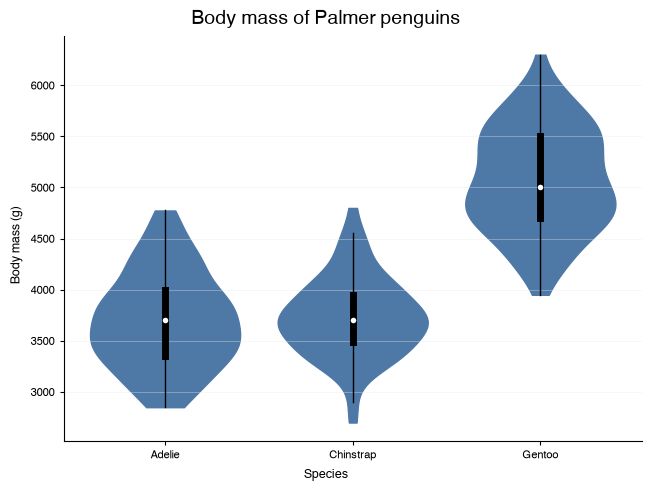

In [5]:
ViolinPlot(
    data=chart_data,
    # add the title
    title="Body mass of Palmer penguins",
    # add the x and y axis labels
    xlabel="Species",
    ylabel="Body mass (g)",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes.

To add the grid, add the `show_grid` attribute. The possible options are:

| Option | Description |
| --- | --- |
| `"both"` | shows both the x-axis and the y-axis gridlines. |
| `"x"` | shows only the x-axis grid lines. |
| `"y"` | shows only the y-axis grid lines. |

Again, `datachart` provides a [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant, which contains the supported options. The values of a vertical violin are read off the y-axis, so the y-axis grid lines are the ones that help.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

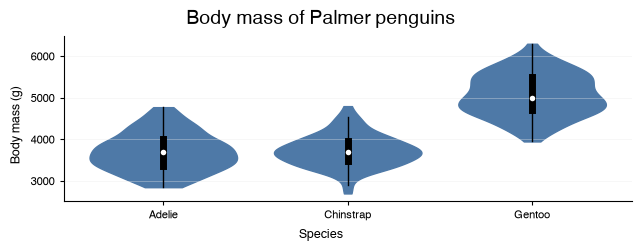

In [7]:
ViolinPlot(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines
    show_grid=SHOW_GRID.Y,
).show()

### Violin style

To change the violin style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.ViolinStyleAttrs](../../../references/typings/#datachart.typings.ViolinStyleAttrs) type: the `plot_violin_color`, `plot_violin_edgecolor`, `plot_violin_alpha`, `plot_violin_linewidth` and `plot_violin_width` attributes style the body, the `plot_violin_inner_*` attributes the marks inside it, and the `plot_violin_median_*` attributes the median dot.

The `style` applies to every violin of the chart. The body fill defaults to the theme's color cycle and the edge to the fill; the inner marks default to the theme's font color, so they read on any fill, and the median dot is white to stand out on the dark quartile bar. Any attribute you leave out keeps the value of the active theme.

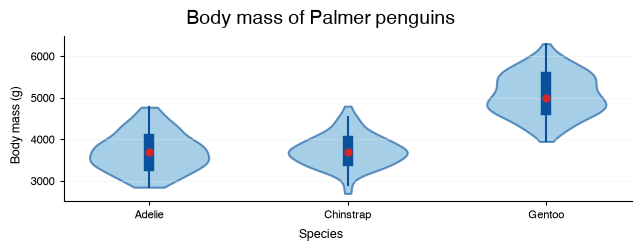

In [8]:
ViolinPlot(
    data=chart_data,
    # define the style of the violins
    style={
        "plot_violin_color": "#6baed6",
        "plot_violin_edgecolor": "#08519c",
        "plot_violin_linewidth": 1.5,
        "plot_violin_alpha": 0.6,
        "plot_violin_width": 0.6,
        "plot_violin_inner_color": "#08519c",
        "plot_violin_inner_linewidth": 1.5,
        "plot_violin_median_color": "#d62728",
        "plot_violin_median_size": 6,
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Inner marks

To change what is drawn inside each body, add the `inner` attribute, which supports the following values:

| Value | Description |
| :---- | :---------- |
| `"box"` | A thin bar from the first to the third quartile, a line reaching the furthest values within 1.5 times the bar height, and a median dot (the default). |
| `"quartiles"` | A dashed median line and dotted first and third quartile lines, each as wide as the body at that value. |
| `"median"` | A single solid median line, as wide as the body at that value. |
| `None` | The body only. |

Again, `datachart` provides a [datachart.constants.VIOLIN_INNER](../../../references/constants/#datachart.constants.VIOLIN_INNER) constant, which contains the supported options. The `"box"` marks summarize the values the way a box plot does; the `"quartiles"` lines show the same quartiles without hiding the shape behind them, and are the better choice when the bodies are narrow or the figure is small.

In [9]:
from datachart.constants import VIOLIN_INNER

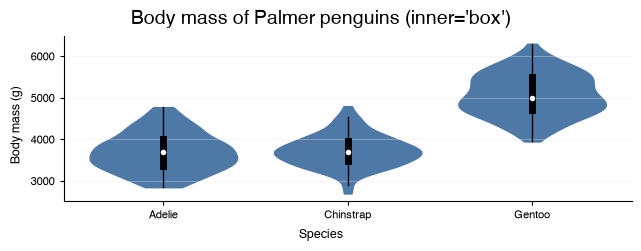

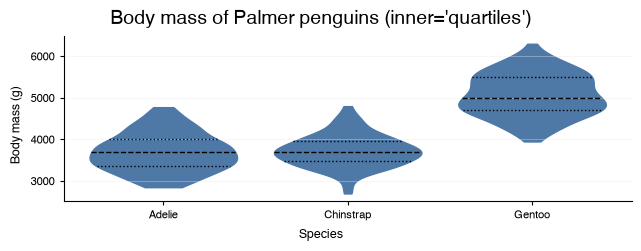

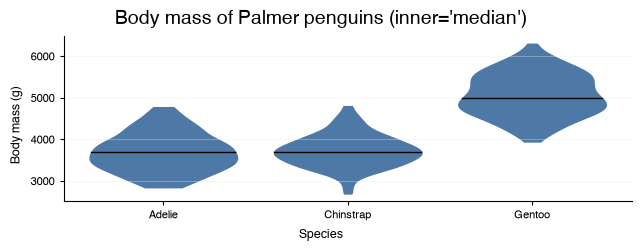

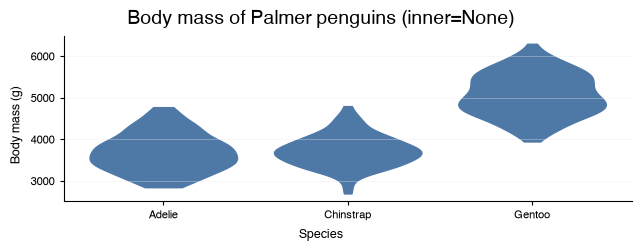

In [10]:
for inner in [VIOLIN_INNER.BOX, VIOLIN_INNER.QUARTILES, VIOLIN_INNER.MEDIAN, None]:
    ViolinPlot(
        data=chart_data,
        # change the marks drawn inside the bodies
        inner=inner,
        title=f"Body mass of Palmer penguins (inner={inner!r})",
        xlabel="Species",
        ylabel="Body mass (g)",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
    ).show()

### Bandwidth

The body is a Gaussian kernel density estimate, and the `bandwidth` attribute sets how wide its kernel is. It takes one of the following values:

| Value | Description |
| :---- | :---------- |
| `"scott"` | Scott's rule of thumb, scaled to the number of values (the default). |
| `"silverman"` | Silverman's rule of thumb, slightly narrower than Scott's for skewed data. |
| a number | A factor applied to the standard deviation of the values; smaller is sharper, larger is smoother. |

A small factor follows every bump of the data and a large one smooths the body into a single hump; the rules of thumb sit in between. The shape can change more than the summary marks, which are computed from the values and never from the estimate.

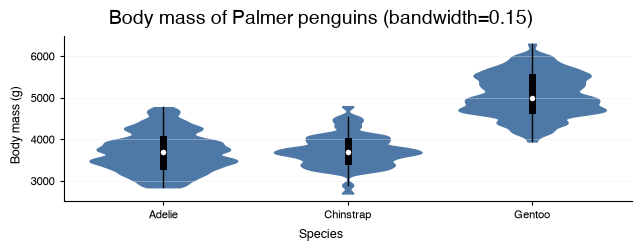

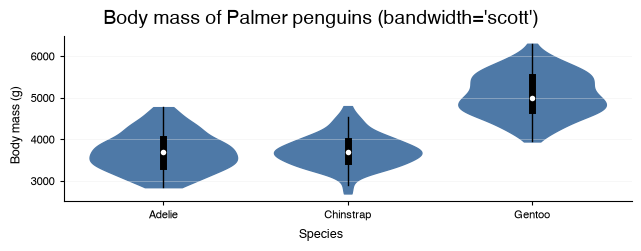

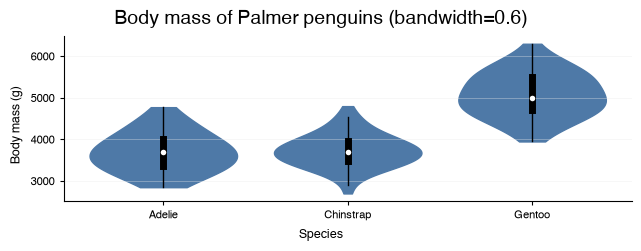

In [11]:
for bandwidth in [0.15, "scott", 0.6]:
    ViolinPlot(
        data=chart_data,
        # sharpen or smooth the bodies
        bandwidth=bandwidth,
        title=f"Body mass of Palmer penguins (bandwidth={bandwidth!r})",
        xlabel="Species",
        ylabel="Body mass (g)",
        figsize=FIG_SIZE.FULL_SHORT,
        show_grid=SHOW_GRID.Y,
    ).show()

### Split violins

To compare two groups within each category, add the `split` attribute with the name of the key in `data` that holds the group of each point. The key must take **exactly two** distinct values across the data; each violin is then cut in half, the left half drawn from the points with the first value and the right half from the points with the second, in the order the values first appear. The halves take the first two colors of the theme's multiple-series palette, each keeps its own inner marks, and `show_legend` lists the two values.

The penguins carry their sex, so `split="sex"` puts the female penguins of each species on the left and the males on the right. A handful of penguins have no recorded sex, which would be a third value, so they are filtered out first.

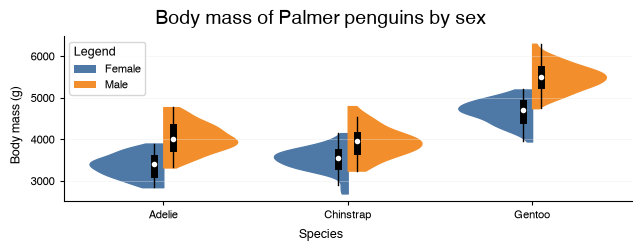

In [12]:
sexed_data = [penguin for penguin in chart_data if penguin["sex"] is not None]

ViolinPlot(
    data=sexed_data,
    # split every violin by the sex of the penguins
    split="sex",
    # list the two split values in the legend
    show_legend=True,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

The `inner` attribute applies to both halves; with `"quartiles"` each half gets its own quartile lines, which makes the difference between the medians easy to read across the centre line.

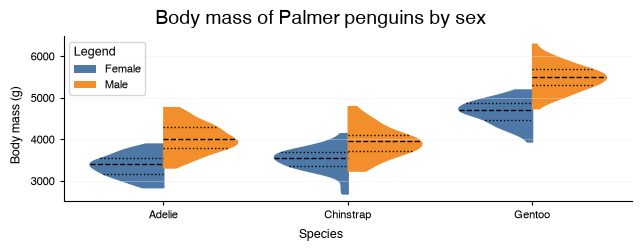

In [13]:
ViolinPlot(
    data=sexed_data,
    split="sex",
    # quartile lines in each half
    inner=VIOLIN_INNER.QUARTILES,
    show_legend=True,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Violin orientation

To change the orientation of the violins, add the `orientation` attribute, which supports the following values:

| Value | Description |
| :---- | :---------- |
| `"vertical"` | The violins are vertical, one per category along the x-axis (the default). |
| `"horizontal"` | The violins are horizontal, one per category along the y-axis. |

Again, `datachart` provides a [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant, which contains the supported options. Horizontal violins swap the roles of the axes: the categories move to the y-axis and the values to the x-axis, so the axis labels and the grid follow.

In [14]:
from datachart.constants import ORIENTATION

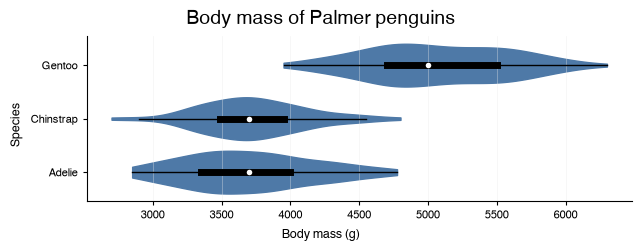

In [15]:
ViolinPlot(
    data=chart_data,
    # change the orientation of the violins
    orientation=ORIENTATION.HORIZONTAL,
    title="Body mass of Palmer penguins",
    # swap the axis labels to match the orientation
    xlabel="Body mass (g)",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    # the values are now read off the x-axis
    show_grid=SHOW_GRID.X,
).show()

### Emphasis

To draw attention to one violin, add the `emphasis` attribute. As with box plots, the `emphasis` list aligns with the violin **labels** of one call, in the order the labels first appear in the data — here Adelie, Chinstrap, Gentoo. Each entry is one of the following roles:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the violin: the body takes the muted color of the active theme, and its inner marks mute together with it. |
| `"highlight"` | Bolds the body edge. |
| `None` | Leaves the violin unchanged. |

A single value instead of a list applies the role to every violin. Again, `datachart` provides a [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant, which contains the supported roles. The example puts the Gentoo violin under scrutiny and pushes the other two species into the background. See the [Highlighting](../../styling/highlighting/) guide for the full picture.

In [16]:
from datachart.constants import EMPHASIS

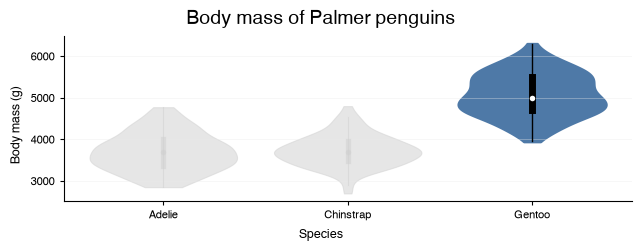

In [17]:
ViolinPlot(
    data=chart_data,
    # one role per violin label: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines

A reference line puts a threshold or a summary value next to the violins. To add horizontal lines, add the `hlines` attribute with the [datachart.typings.HLinePlotAttrs](../../../references/typings/#datachart.typings.HLinePlotAttrs) typing, which is either a `dict` or a `List[dict]`; vertical lines work the same way through the `vlines` attribute and the [datachart.typings.VLinePlotAttrs](../../../references/typings/#datachart.typings.VLinePlotAttrs) typing. The [Box Plot](../boxplot/#reference-lines) guide lists every attribute of a line. The example marks the mean body mass of all penguins.

In [18]:
from datachart.constants import LINE_STYLE

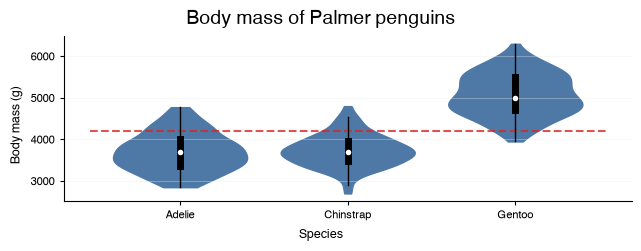

In [19]:
mean_mass = sum(penguin["value"] for penguin in chart_data) / len(chart_data)

ViolinPlot(
    data=chart_data,
    # add a horizontal line at the mean body mass of all penguins
    hlines={
        "y": mean_mass,
        "style": {
            "plot_hline_color": "#d62728",
            "plot_hline_style": LINE_STYLE.DASHED,
            "plot_hline_width": 1.5,
            "plot_hline_alpha": 0.8,
        },
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Violins and boxes together

A violin and a box plot over the same labels draw at the same positions, so the two compose with [datachart.utils.Panel](../../../references/utils#datachart.utils.Panel): the violin with `inner=None` supplies the shape, and the [datachart.charts.BoxPlot](../../../references/charts/#datachart.charts.BoxPlot) drawn over it supplies the full box with its whiskers, caps and outliers. Both charts must group the same labels in the same order; one violin plot and one box plot per panel.

In [20]:
from datachart.charts import BoxPlot
from datachart.utils import Panel

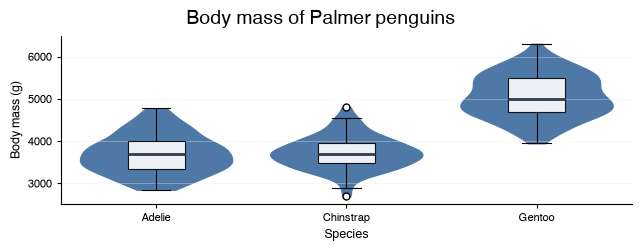

In [21]:
Panel(
    [
        # the body only; the box plot supplies the summaries
        ViolinPlot(data=chart_data, inner=None),
        BoxPlot(
            data=chart_data,
            style={"plot_box_color": "#FFFFFF", "plot_box_alpha": 0.9},
        ),
    ],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Multiple Violin Plots

To create multiple violin plots, pass a list of lists to the `data` argument. Each inner list holds the data points of one chart, which is drawn in its own subplot with the `subtitle` at the top and the `title`, `xlabel` and `ylabel` positioned to be global for all charts. Per-chart attributes like `subtitle` and `style` can be passed as lists, where each element corresponds to a chart; a single value applies to every chart.

<div class="admonition warning">
    <p class="admonition-title">Subplots required for multiple datasets</p>
    <p style="margin-top: .6rem; margin-bottom: .6rem">
        When using multiple datasets (list of lists), you <strong>must</strong> set <code>subplots=True</code>. Violin plots do not support overlaying multiple datasets on a single axis; to compare two groups within each category, use <code>split</code> instead.
    </p>
</div>

The example draws the body mass and the flipper length of the three species side by side. The two charts hold different quantities, so each gets its own subtitle with its unit and there is no global `ylabel`.

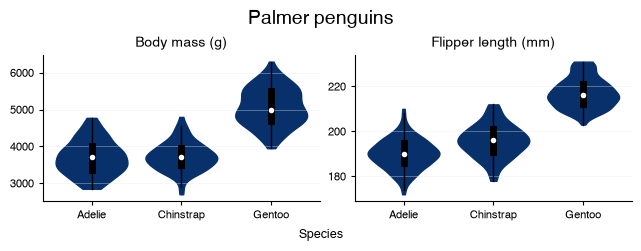

In [22]:
ViolinPlot(
    # use a list of lists to define multiple violin plots
    data=[chart_data, flipper_data],
    # add a subtitle to each chart
    subtitle=["Body mass (g)", "Flipper length (mm)"],
    title="Palmer penguins",
    xlabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # draw each chart in its own subplot
    subplots=True,
).show()

### Shared axes across subplots

To share the x-axis and/or y-axis across subplots, add the `sharex` and/or `sharey` attributes, which are boolean values that specify whether to share the axis across all subplots; a shared axis is labeled once, on the outer subplots only. The `max_cols` attribute limits the number of subplots per row — with `max_cols=1` the charts stack vertically. The `orientation` attribute changes the orientation of every subplot at once: horizontal violins move the species to the y-axis, so side by side it is `sharey` that labels them once, next to the left chart.

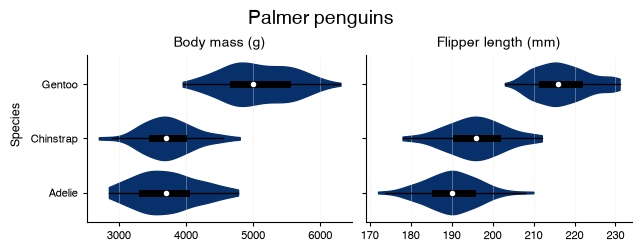

In [23]:
figure = ViolinPlot(
    data=[chart_data, flipper_data],
    subtitle=["Body mass (g)", "Flipper length (mm)"],
    # change the orientation of the violins in every subplot
    orientation=ORIENTATION.HORIZONTAL,
    title="Palmer penguins",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    # the values are now read off the x-axis
    show_grid=SHOW_GRID.X,
    subplots=True,
    # the species are now on the y-axis
    sharey=True,
)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [24]:
from datachart.utils import save_figure

In [25]:
save_figure(figure, "./fig_violin_plot.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell.

### Example 1: Service Response Times (Bimodal Data and a Box Comparison)

`response_times` holds the illustrative response time (in ms) of 300 requests to each of three services, drawn from a seeded generator. Two of the services answer some requests from a cache and the rest from the database, so their response times have two modes — fast cache hits and slow misses — with nothing in between. A box plot reduces each service to one median and one spread, which puts the median of the cached services in a gap where no request actually lands; the violin shows the two humps, and its `"quartiles"` lines make the same point without hiding them. The `Panel` on the right draws the two charts over each other for the comparison.

In [26]:
import numpy as np

rng = np.random.RandomState(7)

# (cache hit share, cache hit ms, database ms) of each service
SERVICES = {
    "Catalog": (0.7, 12, 140),
    "Search": (0.4, 20, 180),
    "Checkout": (0.0, 1, 95),
}
N_REQUESTS = 300

response_times = []
for service, (hit_share, hit_ms, db_ms) in SERVICES.items():
    hits = rng.rand(N_REQUESTS) < hit_share
    fast = rng.lognormal(np.log(hit_ms), 0.2, N_REQUESTS)
    slow = rng.lognormal(np.log(db_ms), 0.25, N_REQUESTS)
    for ms in np.where(hits, fast, slow):
        response_times.append({"label": service, "value": float(ms)})

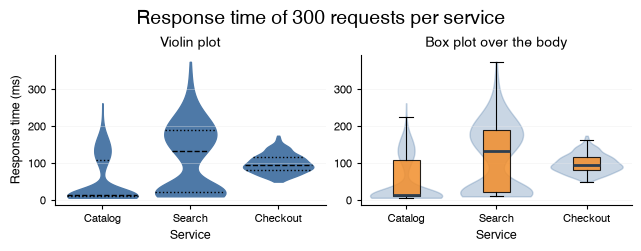

In [27]:
from datachart.utils import Grid

violins = ViolinPlot(
    data=response_times,
    # quartile lines keep the two humps visible
    inner=VIOLIN_INNER.QUARTILES,
    title="Violin plot",
    xlabel="Service",
    ylabel="Response time (ms)",
    show_grid=SHOW_GRID.Y,
)
boxes = Panel(
    [
        ViolinPlot(data=response_times, inner=None, style={"plot_violin_alpha": 0.3}),
        BoxPlot(data=response_times, show_outliers=False),
    ],
    title="Box plot over the body",
    xlabel="Service",
    show_grid=SHOW_GRID.Y,
)

Grid(
    [[violins, boxes]],
    title=f"Response time of {N_REQUESTS} requests per service",
    figsize=FIG_SIZE.FULL_SHORT,
    sharey=True,
).show()

### Example 2: Model Benchmark Across Seeds (Split by Evaluation Split)

`benchmark` holds the illustrative accuracy of four models, each trained with 20 random seeds and evaluated on both the validation and the test split, drawn from a seeded generator. One violin per model split by the evaluation split shows two things at once: how much of the difference between models is seed noise, and whether a model that looks best on validation holds up on test. The `emphasis` mutes the models that are out of the running so the comparison of the two contenders stands out.

In [28]:
rng = np.random.RandomState(11)

# (validation mean, test mean, standard deviation) of the accuracy of each model
MODELS = {
    "Baseline": (0.812, 0.805, 0.020),
    "Wide": (0.838, 0.831, 0.015),
    "Deep": (0.871, 0.846, 0.025),
    "Deep + aug.": (0.868, 0.862, 0.012),
}
N_SEEDS = 20

benchmark = [
    {"label": model, "split": split, "value": float(accuracy)}
    for model, (val_mean, test_mean, std) in MODELS.items()
    for split, mean in [("validation", val_mean), ("test", test_mean)]
    for accuracy in rng.normal(mean, std, N_SEEDS)
]

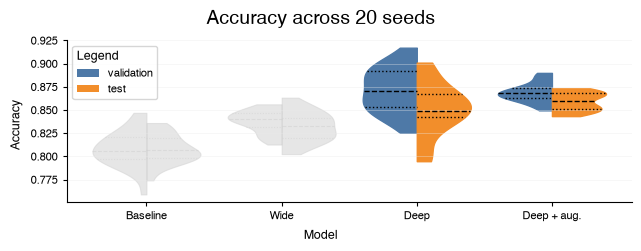

In [29]:
CONTENDERS = {"Deep", "Deep + aug."}

ViolinPlot(
    data=benchmark,
    # the left half is the validation split, the right half the test split
    split="split",
    inner=VIOLIN_INNER.QUARTILES,
    show_legend=True,
    # mute the models that are out of the running
    emphasis=[None if model in CONTENDERS else EMPHASIS.BACKGROUND for model in MODELS],
    title=f"Accuracy across {N_SEEDS} seeds",
    xlabel="Model",
    ylabel="Accuracy",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()